In [53]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

In [54]:
# Read data from CSV file
df = pd.read_csv('records_output.csv')

# Ensure 'Timestamp' is in datetime format
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

In [55]:
# Read data from CSV file
df = pd.read_csv('artificial_movement_data.csv')

# Remove rows where Steps are zero
# df = df[df['Steps'] != 0]

# Convert 'Timestamp' to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Sort the DataFrame by Timestamp
df = df.sort_values(by='Timestamp')

In [56]:
df

,Timestamp,Steps,PAM Score
0,1970-02-01 18:00:00,9,0.00
1,1970-02-01 18:01:00,0,0.00
2,1970-02-01 18:02:00,0,0.00
3,1970-02-01 18:05:00,0,1.99
4,1970-02-01 18:06:00,0,0.02
...,...,...,...
284,1970-02-01 23:55:00,0,0.12
285,1970-02-01 23:56:00,0,0.89
286,1970-02-01 23:57:00,0,0.00
287,1970-02-01 23:59:00,0,0.97


In [57]:
print(df)

              Timestamp  Steps  PAM Score
0   1970-02-01 18:00:00      9       0.00
1   1970-02-01 18:01:00      0       0.00
2   1970-02-01 18:02:00      0       0.00
3   1970-02-01 18:05:00      0       1.99
4   1970-02-01 18:06:00      0       0.02
..                  ...    ...        ...
284 1970-02-01 23:55:00      0       0.12
285 1970-02-01 23:56:00      0       0.89
286 1970-02-01 23:57:00      0       0.00
287 1970-02-01 23:59:00      0       0.97
288 1970-02-02 00:00:00      0       0.00

[289 rows x 3 columns]


In [58]:
# Calculate average PAM score per step
total_steps = df['Steps'].sum()
total_pam_score = df['PAM Score'].sum()

# Avoid division by zero
if total_steps > 0:
    avg_pam_per_step = total_pam_score / total_steps
    print(f"Average PAM Score per Step: {avg_pam_per_step:.4f}")
else:
    print("No steps recorded — cannot compute average PAM Score per Step.")


Average PAM Score per Step: 0.2548


### Visualize the data

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns


class DataVisualizer:
    def __init__(self, data):
        self.data = data

    def plot_pam_score_over_time(self):
        sns.set(style="whitegrid")
        plt.figure(figsize=(12, 6))
        sns.lineplot(x=self.data['Timestamp'],
                     y=self.data['PAM Score'], marker='o')
        plt.title('PAM Score Over Time')
        plt.xlabel('Timestamp')
        plt.ylabel('PAM Score')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    def plot_steps_over_time(self):
        sns.set(style="whitegrid")
        plt.figure(figsize=(12, 6))
        sns.lineplot(x=self.data['Timestamp'],
                     y=self.data['Steps'], marker='s', color='orange')
        plt.title('Steps Over Time')
        plt.xlabel('Timestamp')
        plt.ylabel('Steps')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    def plot_dual_axis(self):
        fig, ax1 = plt.subplots(figsize=(12, 6))
        ax2 = ax1.twinx()
        ax1.plot(self.data['Timestamp'],
                 self.data['Steps'], 'g-', label='Steps')
        ax2.plot(self.data['Timestamp'],
                 self.data['PAM Score'], 'b-', label='PAM Score')

        ax1.set_xlabel('Timestamp')
        ax1.set_ylabel('Steps', color='g')
        ax2.set_ylabel('PAM Score', color='b')
        ax1.tick_params(axis='x', rotation=45)
        plt.title('Steps and PAM Score Over Time')
        fig.tight_layout()
        plt.show()


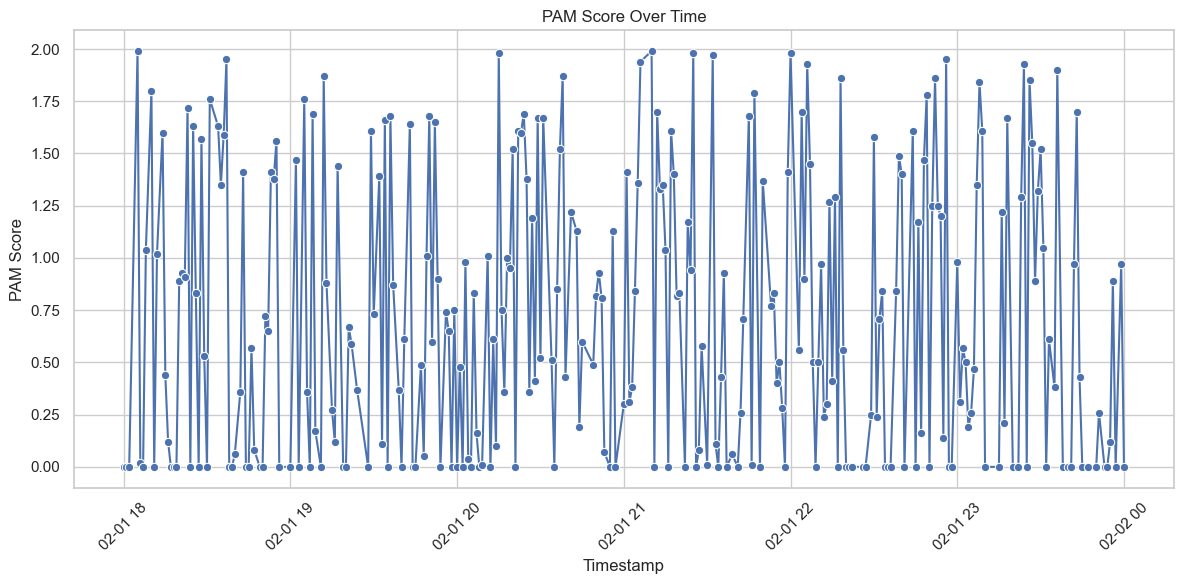

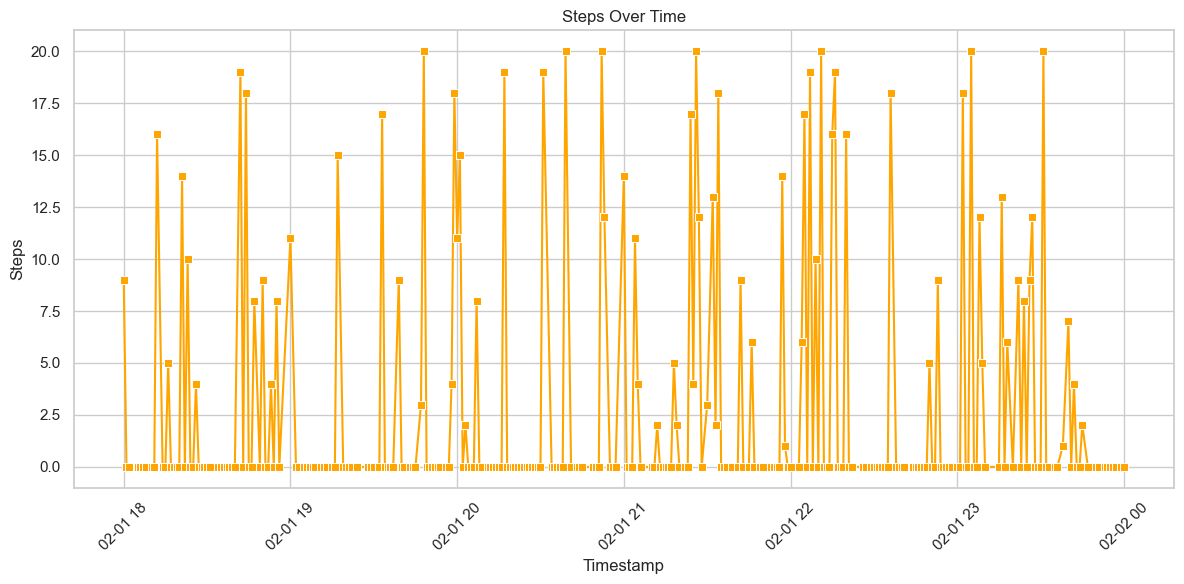

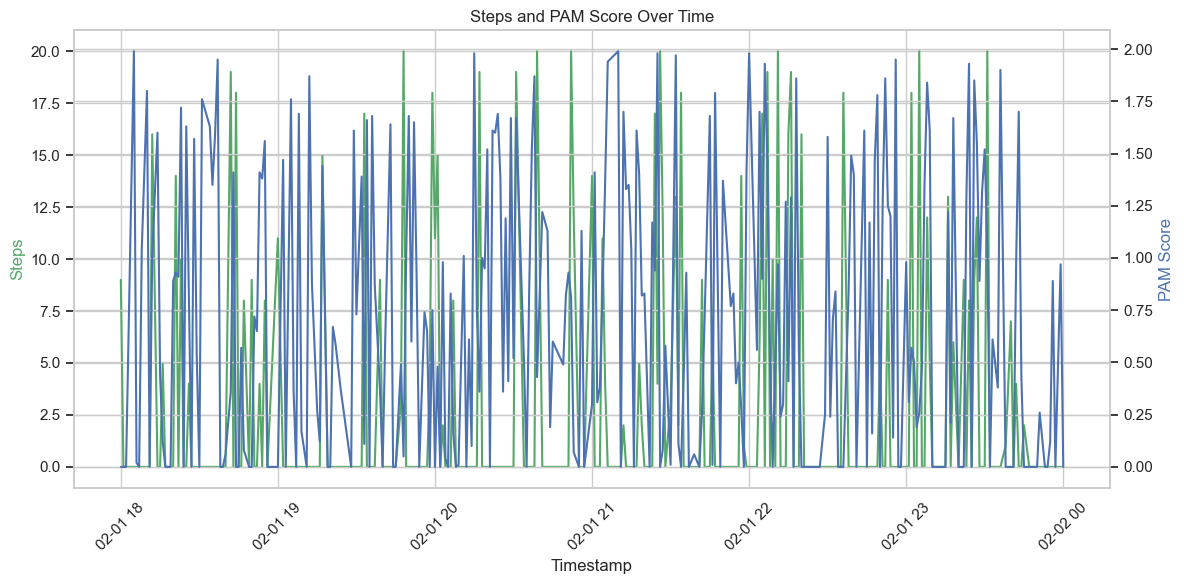

In [60]:
visualizer = DataVisualizer(df)
visualizer.plot_pam_score_over_time()
visualizer.plot_steps_over_time()
visualizer.plot_dual_axis()